In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:

# Display plots inside the notebook
%matplotlib inline

In [ ]:
# Load the dataset
df = pd.read_excel("Flight_Fare.xlsx")

In [ ]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [ ]:
# Shape of the dataset
df.shape

(10683, 11)

In [ ]:
# Column names
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [ ]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [ ]:
# Statistical summary
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [ ]:
# Statistical summary of numerical columns
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [ ]:
# Statistical summary of numerical columns
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [ ]:
df.duplicated().sum()

220

In [ ]:
# Check missing values in each column
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [ ]:
# Remove rows with missing values
df.dropna(inplace=True)

In [ ]:
# Verify that missing values are removed
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [ ]:
# Check the new dataset shape
df.shape

(10682, 11)

In [ ]:
df.duplicated().sum()

220

In [ ]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [ ]:
# Check duplicates again
df.duplicated().sum()

0

In [ ]:
df.shape

(10462, 11)

In [ ]:
# Extract Journey Day
df["Journey_Day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day

# Extract Journey Month
df["Journey_Month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month

In [ ]:
df[["Date_of_Journey", "Journey_Day", "Journey_Month"]].head()

,Date_of_Journey,Journey_Day,Journey_Month
0,24/03/2019,24,3
1,1/05/2019,1,5
2,9/06/2019,9,6
3,12/05/2019,12,5
4,01/03/2019,1,3


In [ ]:
# Remove the original Date_of_Journey column
df.drop("Date_of_Journey", axis=1, inplace=True)

In [ ]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3


In [ ]:
# Extract Departure Hour
df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour

# Extract Departure Minute
df["Dep_Minute"] = pd.to_datetime(df["Dep_Time"]).dt.minute

C:\Users\darji\AppData\Local\Temp\ipykernel_10996\4270417363.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour
C:\Users\darji\AppData\Local\Temp\ipykernel_10996\4270417363.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dep_Minute"] = pd.to_datetime(df["Dep_Time"]).dt.minute


In [ ]:
# Extract Departure Hour
df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"], format="%H:%M").dt.hour

# Extract Departure Minute
df["Dep_Minute"] = pd.to_datetime(df["Dep_Time"], format="%H:%M").dt.minute

In [ ]:
df[["Dep_Time", "Dep_Hour", "Dep_Minute"]].head()

,Dep_Time,Dep_Hour,Dep_Minute
0,22:20,22,20
1,05:50,5,50
2,09:25,9,25
3,18:05,18,5
4,16:50,16,50


In [ ]:
# Remove Dep_Time column
df.drop("Dep_Time", axis=1, inplace=True)

In [ ]:
df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,16,50


In [ ]:
# Extract Arrival Hour
df["Arrival_Hour"] = pd.to_datetime(
    df["Arrival_Time"].str.split().str[0],
    format="%H:%M"
).dt.hour

# Extract Arrival Minute
df["Arrival_Minute"] = pd.to_datetime(
    df["Arrival_Time"].str.split().str[0],
    format="%H:%M"
).dt.minute

In [ ]:
df[["Arrival_Time", "Arrival_Hour", "Arrival_Minute"]].head()

,Arrival_Time,Arrival_Hour,Arrival_Minute
0,01:10 22 Mar,1,10
1,13:15,13,15
2,04:25 10 Jun,4,25
3,23:30,23,30
4,21:35,21,35


In [ ]:
# Remove Arrival_Time column
df.drop("Arrival_Time", axis=1, inplace=True)

In [ ]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


In [ ]:
# Extract Duration Hours
df["Duration_Hours"] = df["Duration"].str.extract(r"(\d+)h").fillna(0).astype(int)

# Extract Duration Minutes
df["Duration_Minutes"] = df["Duration"].str.extract(r"(\d+)m").fillna(0).astype(int)

In [ ]:
df[["Duration", "Duration_Hours", "Duration_Minutes"]].head(10)

,Duration,Duration_Hours,Duration_Minutes
0,2h 50m,2,50
1,7h 25m,7,25
2,19h,19,0
3,5h 25m,5,25
4,4h 45m,4,45
5,2h 25m,2,25
6,15h 30m,15,30
7,21h 5m,21,5
8,25h 30m,25,30
9,7h 50m,7,50


In [ ]:
# Remove Duration column
df.drop("Duration", axis=1, inplace=True)

In [ ]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Hours,Duration_Minutes
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45


In [ ]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour',
       'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute', 'Duration_Hours',
       'Duration_Minutes'],
      dtype='object')

In [ ]:
df["Airline"].value_counts()

Airline
Jet Airways                          3700
IndiGo                               2042
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
                                        1
Trujet                                  1
Name: count, dtype: int64

In [ ]:
df["Source"].value_counts()

Source
Delhi       4345
Kolkata     2860
Banglore    2179
Mumbai       697
Chennai      381
Name: count, dtype: int64

In [ ]:
df["Destination"].value_counts()

Destination
Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [ ]:
df["Total_Stops"].value_counts()

Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64

In [ ]:
df["Additional_Info"].value_counts()

Additional_Info
No info                         8182
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [ ]:
df["Route"].nunique()

128

In [ ]:
# Encode Total_Stops
df["Total_Stops"] = df["Total_Stops"].replace({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

In [ ]:
df["Total_Stops"].head(10)

0    0
1    2
2    2
3    1
4    1
5    0
6    1
7    1
8    1
9    1
Name: Total_Stops, dtype: int64

In [ ]:
# One-Hot Encode categorical columns
df = pd.get_dummies(
    df,
    columns=["Airline", "Source", "Destination", "Additional_Info"],
    drop_first=True,
    dtype=int
)

In [ ]:
df.head()

,Route,Total_Stops,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Hours,...,Destination_New Delhi,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,BLR → DEL,0,3897,24,3,22,20,1,10,2,...,1,0,0,0,0,0,0,0,1,0
1,CCU → IXR → BBI → BLR,2,7662,1,5,5,50,13,15,7,...,0,0,0,0,0,0,0,0,1,0
2,DEL → LKO → BOM → COK,2,13882,9,6,9,25,4,25,19,...,0,0,0,0,0,0,0,0,1,0
3,CCU → NAG → BLR,1,6218,12,5,18,5,23,30,5,...,0,0,0,0,0,0,0,0,1,0
4,BLR → NAG → DEL,1,13302,1,3,16,50,21,35,4,...,1,0,0,0,0,0,0,0,1,0


In [ ]:
df.shape

(10462, 41)

In [ ]:
# Remove Route column
df.drop("Route", axis=1, inplace=True)

In [ ]:
df.columns

Index(['Total_Stops', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour',
       'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute', 'Duration_Hours',
       'Duration_Minutes', 'Airline_Air Asia', 'Airline_Air India',
       'Airline_GoAir', 'Airline_IndiGo', 'Airline_Jet Airways',
       'Airline_Jet Airways Business', 'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi',
       'Additional_Info_1 Short layover', 'Additional_Info_2 Long layover',
       'Additional_Info_Business class', 'Additional_Info_Change airports',
       'Additional_Info_In-flight meal not included',
       'Additional_Info_No Info',
       'Additional_Info_No check-in baggage included',

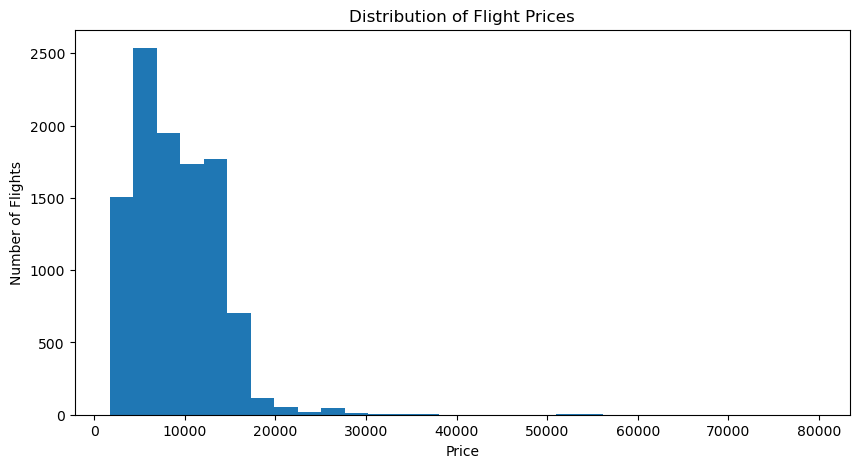

In [ ]:
import matplotlib.pyplot as plt  ## Price Distribution

plt.figure(figsize=(10,5))
plt.hist(df["Price"], bins=30)
plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Number of Flights")
plt.show()

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Airline", y="Price", data=df_original)
plt.xticks(rotation=90)
plt.title("Airline vs Flight Price")
plt.show()

NameError: name 'df_original' is not defined

<Figure size 1200x600 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.columns

In [ ]:
df

In [ ]:
# Create a separate dataframe for EDA
eda_df = pd.read_excel("Flight_Fare.xlsx")

In [ ]:
eda_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


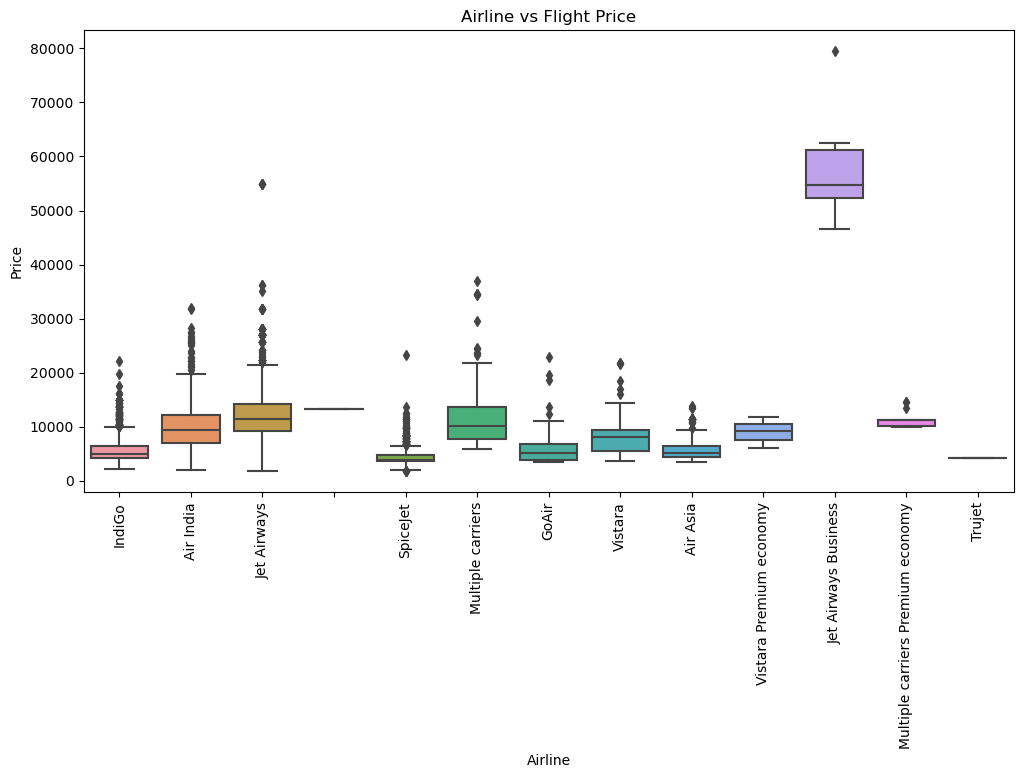

In [ ]:
plt.figure(figsize=(12,6))  ## Airline vs Flight Price
sns.boxplot(x="Airline", y="Price", data=eda_df)
plt.xticks(rotation=90)
plt.title("Airline vs Flight Price")
plt.xlabel("Airline")
plt.ylabel("Price")
plt.show()

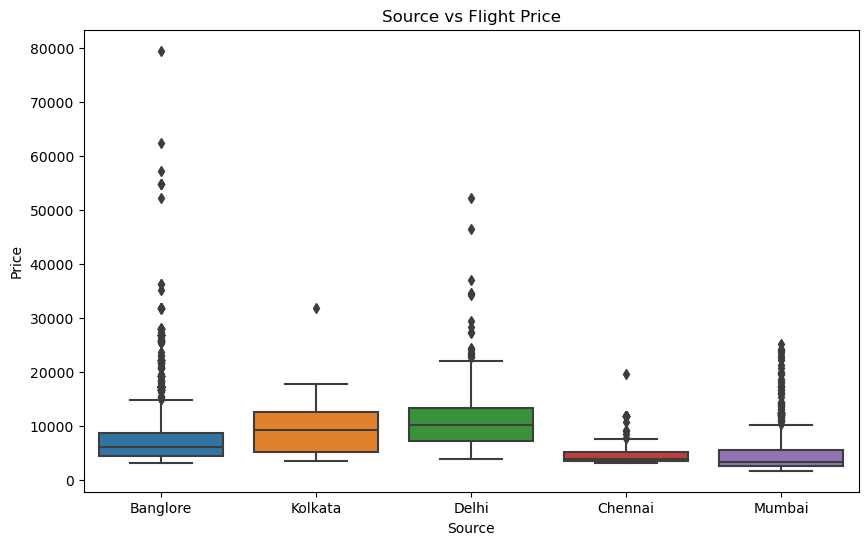

In [ ]:
plt.figure(figsize=(10,6))   ## Source vs Flight Price

sns.boxplot(x="Source", y="Price", data=eda_df)

plt.title("Source vs Flight Price")
plt.xlabel("Source")
plt.ylabel("Price")

plt.show()

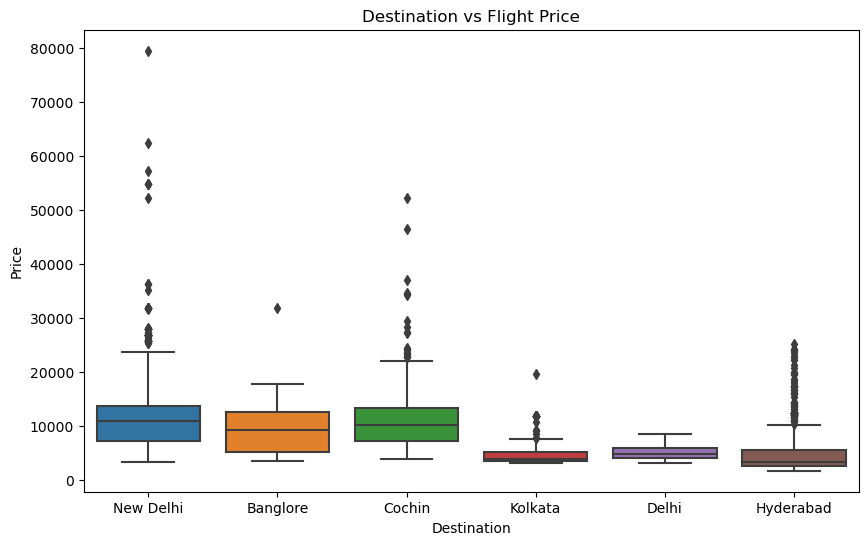

In [ ]:
plt.figure(figsize=(10,6))  ## Destination vs Flight Price

sns.boxplot(x="Destination", y="Price", data=eda_df)

plt.title("Destination vs Flight Price")
plt.xlabel("Destination")
plt.ylabel("Price")

plt.show()

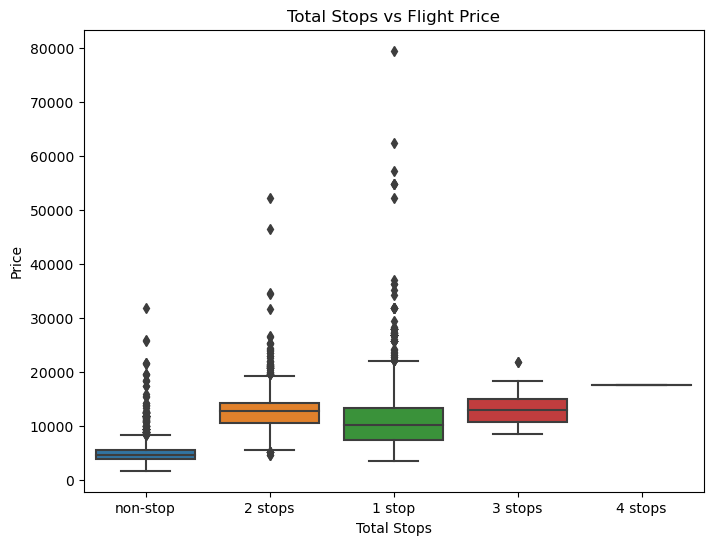

In [ ]:
plt.figure(figsize=(8,6))  ## Total Stops vs Flight Price

sns.boxplot(x="Total_Stops", y="Price", data=eda_df)

plt.title("Total Stops vs Flight Price")
plt.xlabel("Total Stops")
plt.ylabel("Price")

plt.show()

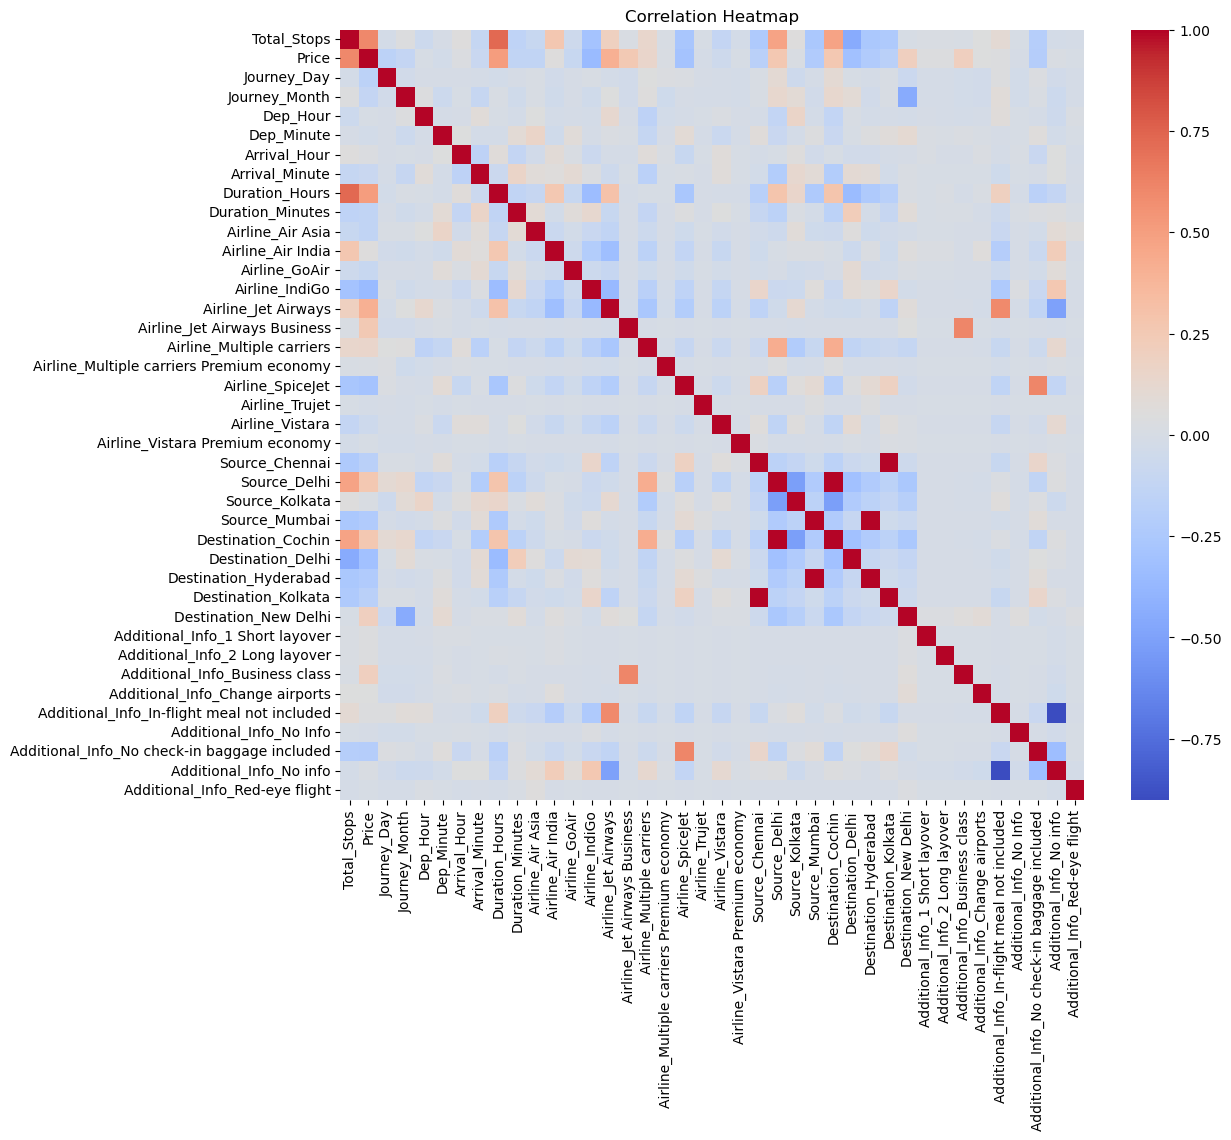

In [ ]:
plt.figure(figsize=(12,10))  ## Correlation Heatmap

sns.heatmap(df.corr(), cmap="coolwarm", annot=False)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Features (Independent Variables)
X = df.drop("Price", axis=1)

# Target (Dependent Variable)
y = df["Price"]

In [ ]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (10462, 39)
y Shape : (10462,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (8369, 39)
X_test Shape : (2093, 39)
y_train Shape: (8369,)
y_test Shape : (2093,)


In [ ]:
from sklearn.linear_model import LinearRegression  ## Linear Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predict on test data
y_pred_lr = lr_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

Linear Regression Results
MAE : 1772.24
MSE : 7053914.19
RMSE: 2655.92
R2 Score: 0.6617


In [ ]:
from sklearn.tree import DecisionTreeRegressor  ## Decision Tree Regressor

# Create Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict on test data
y_pred_dt = dt_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

Decision Tree Results
MAE : 792.44
MSE : 3663412.66
RMSE: 1914.0
R2 Score: 0.8243


In [ ]:
from sklearn.ensemble import RandomForestRegressor  ## Random Forest Regressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

Random Forest Results
MAE : 681.37
MSE : 2218033.84
RMSE: 1489.31
R2 Score: 0.8936


# Model Comparison Report

Linear Regression
MAE = 1772.24
RMSE = 2655.92
R2 Score = 0.6617

Decision Tree
MAE = 792.44
RMSE = 1914.00
R2 Score = 0.8243

Random Forest
MAE = 681.37
RMSE = 1489.31
R2 Score = 0.8936

Conclusion:
Random Forest Regressor achieved the best performance.

# Challenges Faced

1. The dataset contained missing values in the Route and Total_Stops columns.

2. Date and time columns were not directly suitable for machine learning, so feature engineering was performed.

3. Categorical columns such as Airline, Source, Destination and Additional_Info were converted into numerical values using One-Hot Encoding.

4. The Route column was removed because similar information was already available in the Source and Destination columns.

5. Different machine learning models were trained and compared to select the best-performing model.

Techniques Used

- Data Cleaning
- Feature Engineering
- One-Hot Encoding
- Train-Test Split
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

# Conclusion

The Flight Price Prediction project was completed using Exploratory Data Analysis and Machine Learning techniques.

The dataset was cleaned, transformed, and prepared using feature engineering and One-Hot Encoding.

Three regression models were developed and evaluated:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Among these models, Random Forest Regressor achieved the best performance with an R2 Score of 0.8936 and the lowest prediction error.

Therefore, Random Forest Regressor is recommended as the final model for predicting future flight prices.